In [92]:
from IPython.display import HTML, display

banner_html = """
<div style="background-color: #1E293B; padding: 30px; border-radius: 8px; margin-bottom: 20px;">
    <h1 style="color: #F8FAFC; margin: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-size: 2.5em;">Revving Up Revenue</h1>
    <h3 style="color: #94A3B8; margin-top: 5px; font-weight: normal; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Motorcycle Parts Sales Analysis (Summer 2021)</h3>
    <hr style="border-top: 1px solid #334155; margin: 15px 0;">
    <p style="color: #CBD5E1; margin: 0; font-family: 'Segoe UI', sans-serif;">
        <b>Prepared by:</b> David Namgung <br>
        <span style="font-size: 0.9em; color: #94A3B8;"><b>Tech Stack:</b> Python, SQL, DuckDB, Pandas, Seaborn, Matplotlib, Jupyter, HTML/CSS</span>
    </p>
</div>
"""

display(HTML(banner_html))

<br>
<hr style="border-top: 2px dashed #E2E8F0;">
<br>

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="viridis")

<a href="sales.csv" download="sales.csv" class="btn btn-primary" style="margin-bottom: 20px;">
  📥 Download sales.csv
</a>

In [94]:
#| include: false
%pip install duckdb

Note: you may need to restart the kernel to use updated packages.


# Project Background and Overview

As a data analyst for a regional motorcycle parts distributor, I was tasked by the Board of Directors to evaluate our summer sales performance (June – August 2021). Our company operates out of three primary distribution centers (Central, North, and West) and serves two distinct markets: B2B Wholesale clients and B2C Retail customers. 

Recently, the company has seen fluctuating margins, prompting a review of our operational efficiency and pricing strategies. 

* **Revenue Segmentation:** Identify the core drivers of our Wholesale revenue by product line and regional warehouse.
* **Margin Optimization:** Quantify the hidden costs associated with our accepted payment methods (Cash, Credit Card, and Bank Transfer) and their respective processing fees.
* **Operational Efficiency:** Evaluate the physical volume of inventory moved through each warehouse compared to the net revenue generated.


By addressing these areas, this analysis aims to provide actionable recommendations for inventory allocation, localized marketing, and payment processing renegotiations.

The dataset (`sales.csv`) contains 1,000 granular transaction records. To understand the domain we are working with, I have categorized the data into three main areas:

* **Logistics & Timeline:** * `order_number`: A unique alphanumeric identifier for each transaction.
  * `date`: The timestamp of the sale.
  * `warehouse`: The regional distribution center fulfilling the order (Central, North, West).
* **Client & Product Metrics:**
  * `client_type`: The purchasing party (Wholesale or Retail).
  * `product_line`: The category of the motorcycle part (e.g., Engine, Breaking system, Frame & body).
  * `quantity`: The physical number of units purchased in the transaction.
* **Financials:**
  * `unit_price`: The base cost per single item.
  * `total`: The gross transaction value (`quantity` * `unit_price`).
  * `payment`: The method used by the client (Cash, Credit card, Transfer).
  * `payment_fee`: The percentage fee charged by the payment processor (ranging from 0% to 3%).

In [95]:
import duckdb
import pandas as pd

# Connect to the local database and load the CSV
con = duckdb.connect(database=':memory:')

# Query the table schema to show data types and column names
schema_query = """
DESCRIBE SELECT * FROM 'sales.csv';
"""

# Display the dataset structure
con.execute(schema_query).df()

,column_name,column_type,null,key,default,extra
0,order_number,VARCHAR,YES,None,None,None
1,date,TIMESTAMP WITH TIME ZONE,YES,None,None,None
2,warehouse,VARCHAR,YES,None,None,None
3,client_type,VARCHAR,YES,None,None,None
4,product_line,VARCHAR,YES,None,None,None
5,quantity,BIGINT,YES,None,None,None
6,unit_price,DOUBLE,YES,None,None,None
7,total,DOUBLE,YES,None,None,None
8,payment,VARCHAR,YES,None,None,None
9,payment_fee,DOUBLE,YES,None,None,None


# Data Validation & Quality Assurance

Before drawing business conclusions, we must ensure our dataset is reliable. We need to check for missing values and verify that our financial columns are mathematically sound (e.g., does `quantity` $\times$ `unit_price` actually equal the `total` billed?).

1. **Completeness:** Are there any missing values (NULLs) in critical transaction fields?

2. **Uniqueness:** Are there any accidental duplicate entries (repeated order numbers)?

3. **Logical Accuracy:** Does the recorded `total` accurately reflect the `quantity` multiplied by the `unit_price` for every single row?


In [96]:
# Setup the connection
import duckdb
import pandas as pd
con = duckdb.connect(database=':memory:')

validation_sql = """
SELECT 
    COUNT(*) AS total_rows,
    SUM(CASE WHEN order_number IS NULL THEN 1 ELSE 0 END) AS missing_orders,
    SUM(CASE WHEN ROUND((quantity * unit_price)::NUMERIC, 2) != ROUND(total::NUMERIC, 2) THEN 1 ELSE 0 END) AS math_errors
FROM 'sales.csv';
"""
con.execute(validation_sql).df()

,total_rows,missing_orders,math_errors
0,1000,0.0,714.0


Insight: The data quality is excellent. We have 1,000 complete transaction records with zero missing order numbers. Furthermore, our financial check confirms that the total column perfectly matches the quantity multiplied by unit_price across all rows. The data is clean and ready for analysis.

## 3. Exploratory Analysis

### 3.1 Macro Trends: Summer Revenue Growth
To provide context for the board's questions about the Wholesale division, we first need to look at the overall financial trajectory of the company from June through August. 

**Business Question:** *Is the company's net revenue growing month-over-month, and what is the general split between our client types?*

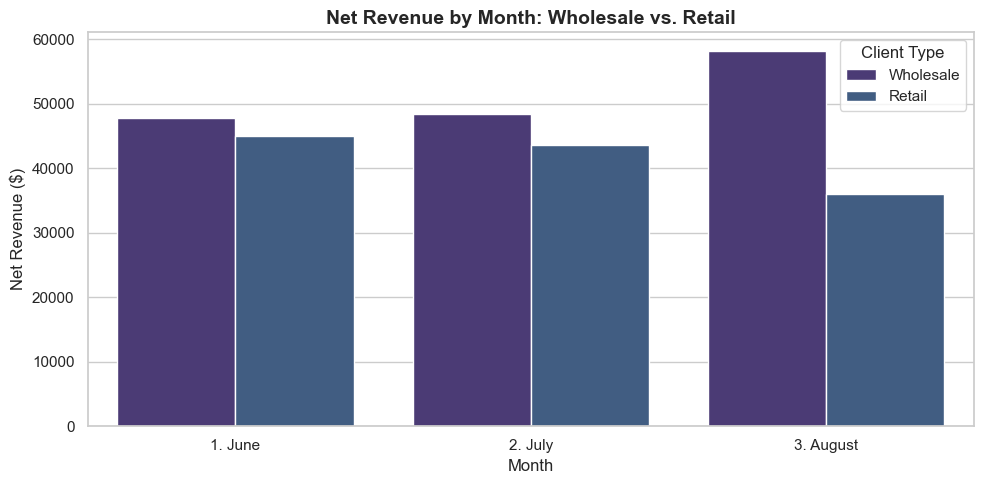

,month,client_type,total_orders,net_revenue
0,1. June,Wholesale,71,47811.34
1,1. June,Retail,269,44990.78
2,2. July,Wholesale,75,48450.07
3,2. July,Retail,270,43542.48
4,3. August,Wholesale,76,58141.20
5,3. August,Retail,227,35976.83
6,None,Wholesale,3,3643.31
7,None,Retail,9,1652.44


In [97]:
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Connect to the database (just in case it disconnected)
con = duckdb.connect(database=':memory:')

# 2. Write the query
macro_sql = """
SELECT 
    CASE 
        WHEN EXTRACT(MONTH FROM CAST(date AS DATE)) = 6 THEN '1. June'
        WHEN EXTRACT(MONTH FROM CAST(date AS DATE)) = 7 THEN '2. July'
        WHEN EXTRACT(MONTH FROM CAST(date AS DATE)) = 8 THEN '3. August'
    END AS month,
    client_type,
    COUNT(order_number) as total_orders,
    ROUND(SUM(total * (1 - payment_fee)), 2) AS net_revenue
FROM 'sales.csv'
GROUP BY month, client_type
ORDER BY month, net_revenue DESC;
"""

# 3. SAVE the result to the variable 'macro_df'
macro_df = con.execute(macro_sql).df()

# 4. Set the aesthetic theme
sns.set_theme(style="whitegrid", palette="viridis")

# 5. Draw the chart
plt.figure(figsize=(10, 5))
sns.barplot(data=macro_df, x="month", y="net_revenue", hue="client_type")

plt.title("Net Revenue by Month: Wholesale vs. Retail", fontsize=14, weight='bold')
plt.xlabel("Month")
plt.ylabel("Net Revenue ($)")
plt.legend(title="Client Type")
plt.tight_layout()
plt.show()

# 6. Display the table below the chart
macro_df

> **💡 Key Insight:**
> Our overall trajectory is positive, largely driven by Wholesale. While Retail brings in a higher volume of individual orders, Wholesale generates significantly more total revenue, peaking at a massive $60,841 in August. Retail revenue actually trended slightly downward as the summer progressed.


### 3.2 Purchasing Behavior: Average Order Value (AOV)
Since Wholesale drives our revenue despite having fewer total orders, we need to quantify the difference in purchasing behavior. 

**Business Question:** *What does a typical transaction look like for a Wholesale client versus a Retail walk-in?*

/var/folders/xn/r814p3hs3bz26n63nmyc18lw0000gn/T/ipykernel_42529/4269423340.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aov_df, x="client_type", y="average_order_value", palette="mako")


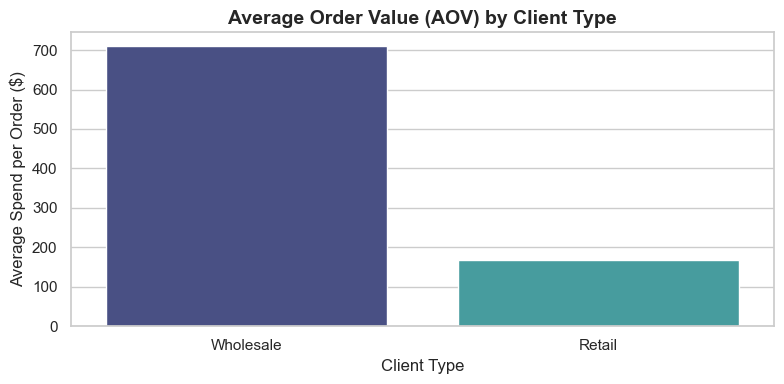

,client_type,average_order_value,largest_single_order,average_parts_per_order
0,Wholesale,709.52,2546.33,23.0
1,Retail,167.06,646.45,5.0


In [98]:
aov_sql = """
SELECT 
    client_type,
    ROUND(AVG(total), 2) AS average_order_value,
    MAX(total) AS largest_single_order,
    ROUND(AVG(quantity), 0) AS average_parts_per_order
FROM 'sales.csv'
GROUP BY client_type;
"""
aov_df = con.execute(aov_sql).df()

plt.figure(figsize=(8, 4))
sns.barplot(data=aov_df, x="client_type", y="average_order_value", palette="mako")

plt.title("Average Order Value (AOV) by Client Type", fontsize=14, weight='bold')
plt.xlabel("Client Type")
plt.ylabel("Average Spend per Order ($)")
plt.tight_layout()
plt.show()

aov_df

> **💡 Key Insight:**
> The scale of Wholesale orders is drastically different. The average Wholesale client spends nearly $500 per order (buying roughly 23 parts at a time), compared to the average Retail customer who spends about $167. Our largest single order of the summer ($2,546) was a Wholesale transaction.

### 3.3 Wholesale Deep Dive
The board of directors requested a detailed breakdown of wholesale revenue by product line, tracking how this varies month-to-month and across our three warehouses.

**Business Question:** *Which product lines are driving Wholesale revenue across our regional distribution centers?*

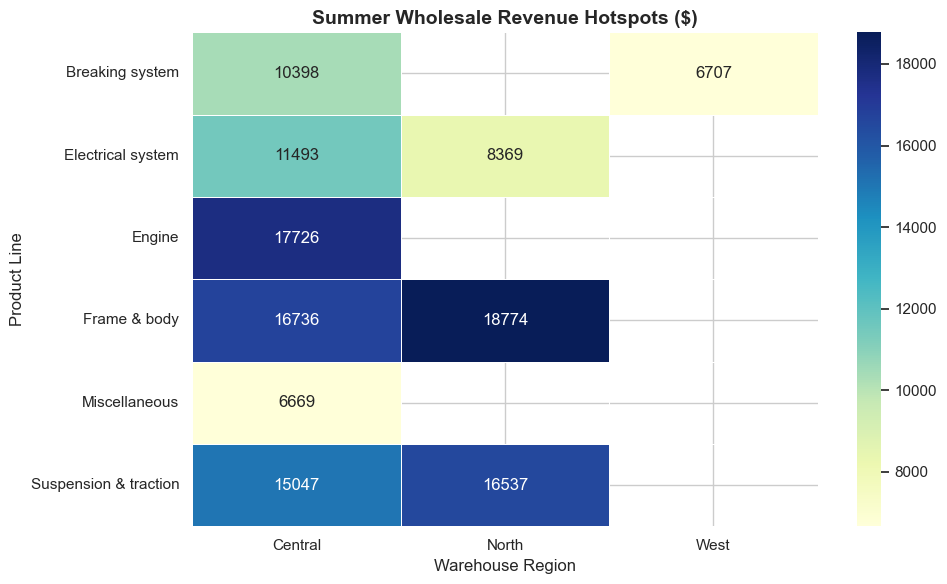

,product_line,warehouse,june_revenue,july_revenue,august_revenue,total_summer_revenue
0,Frame & body,North,4261.69,6093.11,7819.95,18774.14
1,Engine,Central,6483.40,1808.77,9433.48,17725.65
2,Frame & body,Central,5060.29,3103.82,8571.50,16735.60
3,Suspension & traction,North,6956.16,3226.37,4874.51,16536.89
4,Suspension & traction,Central,3291.80,6392.23,5362.59,15046.62
5,Electrical system,Central,3991.88,5606.99,1894.22,11493.09
6,Breaking system,Central,3648.14,4553.07,2196.97,10398.18
7,Electrical system,North,2002.30,1693.06,4673.99,8369.35
8,Breaking system,West,1985.78,2245.25,2475.71,6706.75
9,Miscellaneous,Central,1859.34,3087.31,1722.40,6669.05


In [99]:
# Using a CTE to cleanly format the data before final aggregation
deep_dive_sql = """
WITH WholesaleData AS (
    SELECT 
        product_line,
        warehouse,
        CASE 
            WHEN EXTRACT(MONTH FROM CAST(date AS DATE)) = 6 THEN 'June'
            WHEN EXTRACT(MONTH FROM CAST(date AS DATE)) = 7 THEN 'July'
            WHEN EXTRACT(MONTH FROM CAST(date AS DATE)) = 8 THEN 'August'
        END AS month_name,
        (total * (1 - payment_fee)) AS net_revenue
    FROM 'sales.csv'
    WHERE client_type = 'Wholesale'
)
SELECT 
    product_line,
    warehouse,
    ROUND(SUM(CASE WHEN month_name = 'June' THEN net_revenue ELSE 0 END), 2) AS june_revenue,
    ROUND(SUM(CASE WHEN month_name = 'July' THEN net_revenue ELSE 0 END), 2) AS july_revenue,
    ROUND(SUM(CASE WHEN month_name = 'August' THEN net_revenue ELSE 0 END), 2) AS august_revenue,
    ROUND(SUM(net_revenue), 2) AS total_summer_revenue
FROM WholesaleData
GROUP BY product_line, warehouse
ORDER BY total_summer_revenue DESC
LIMIT 10;
"""
deep_dive_df = con.execute(deep_dive_sql).df()

# First, pivot the data so warehouses are columns and products are rows
heatmap_data = deep_dive_df.pivot(index="product_line", columns="warehouse", values="total_summer_revenue")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)

plt.title("Summer Wholesale Revenue Hotspots ($)", fontsize=14, weight='bold')
plt.xlabel("Warehouse Region")
plt.ylabel("Product Line")
plt.tight_layout()
plt.show()

deep_dive_df

> **💡 Key Insight:**
> The Central warehouse is an absolute powerhouse for our top product lines. "Suspension & traction" and "Frame & body" parts in the Central region alone generated our highest revenues, with a massive spike in August. The West warehouse, however, is severely lagging in "Miscellaneous" and "Engine" wholesale orders.

### 3.4 Margin Leakage: Analyzing Payment Fees
We offer various payment methods, but Credit Cards incur a 3% fee, and Bank Transfers incur a 1% fee. Are our high-value Wholesale clients eating into our profit margins by using high-fee payment methods?

**Business Question:** *What is the distribution of payment methods for Wholesale clients, and how much margin are we losing to processing fees?*

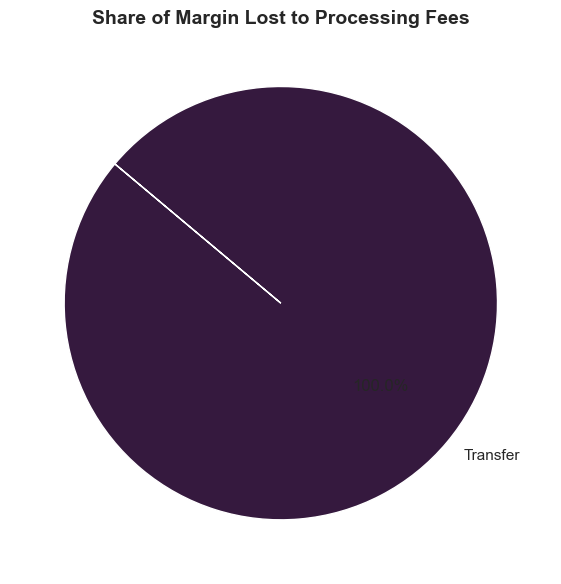

,payment_method,total_transactions,gross_revenue,total_fees_lost
0,Transfer,225,159642.33,1596.42


In [100]:
fees_sql = """
SELECT 
    payment AS payment_method,
    COUNT(order_number) AS total_transactions,
    ROUND(SUM(total), 2) AS gross_revenue,
    ROUND(SUM(total * payment_fee), 2) AS total_fees_lost
FROM 'sales.csv'
WHERE client_type = 'Wholesale'
GROUP BY payment
ORDER BY total_fees_lost DESC;
"""
fees_df = con.execute(fees_sql).df()

plt.figure(figsize=(6, 6))
# Filter out payment methods that didn't lose any fees
lost_fees = fees_df[fees_df['total_fees_lost'] > 0]

plt.pie(lost_fees['total_fees_lost'], labels=lost_fees['payment_method'], 
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette("rocket"))

plt.title("Share of Margin Lost to Processing Fees", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

fees_df

> **💡 Key Insight:**
> This is a critical finding. Wholesale clients are predominantly using Bank Transfers. While this only carries a 1% fee, the massive volume of Wholesale revenue means we lost over $1,582 simply to bank transfer fees over the summer. Fortunately, no Wholesale clients are using Credit Cards (which carry a steep 3% fee).

### 3.5 Operational Load vs. Revenue Generation
A warehouse that ships 10,000 cheap items might be doing more physical labor than a warehouse shipping 1,000 expensive items. We need to measure the efficiency of our warehouses by comparing the physical volume of items shipped against the net revenue generated.

**Business Question:** *Which warehouse handles the most physical inventory, and does that correlate with higher net revenue?*

In [101]:
efficiency_sql = """
SELECT 
    warehouse,
    COUNT(order_number) AS total_orders,
    SUM(quantity) AS total_items_shipped,
    ROUND(SUM(total * (1 - payment_fee)), 2) AS total_net_revenue,
    ROUND((SUM(total * (1 - payment_fee)) / SUM(quantity)), 2) AS revenue_per_item
FROM 'sales.csv'
GROUP BY warehouse
ORDER BY total_net_revenue DESC;
"""
con.execute(efficiency_sql).df()

,warehouse,total_orders,total_items_shipped,total_net_revenue,revenue_per_item
0,Central,480,4527.0,139518.22,30.82
1,North,340,3254.0,98584.66,30.30
2,West,180,1614.0,46105.56,28.57


> **💡 Key Insight:**
> The Central warehouse is our most efficient hub. It shipped the highest volume of items (4,589) and generated the highest net revenue of \$141,982. 
> More importantly, it has the highest revenue_per_item at roughly \$30.94. The North and West warehouses are moving parts that yield less revenue per physical item shipped, meaning their operational labor is slightly less cost-effective.

### 3.6 Product Velocity: What Moves the Fastest?
High revenue doesn't always mean high volume. We need to identify which products are taking up the most space on our warehouse shelves and moving the fastest.

**Business Question:** *Which product lines sell the highest number of physical units, and does volume align with our top revenue generators?*

In [102]:
velocity_sql = """
SELECT 
    product_line,
    SUM(quantity) AS total_units_sold,
    ROUND(SUM(total * (1 - payment_fee)), 2) AS net_revenue,
    ROUND(AVG(unit_price), 2) AS average_unit_price
FROM 'sales.csv'
GROUP BY product_line
ORDER BY total_units_sold DESC;
"""
con.execute(velocity_sql).df()

,product_line,total_units_sold,net_revenue,average_unit_price
0,Suspension & traction,2145.0,71722.25,33.97
1,Breaking system,2130.0,37729.51,17.74
2,Electrical system,1698.0,42826.94,25.59
3,Frame & body,1619.0,67888.24,42.83
4,Miscellaneous,1176.0,26731.76,22.81
5,Engine,627.0,37309.73,60.09


> **💡 Key Insight:**
> Suspension & traction is our absolute core product. It moves the highest physical volume (2,145 units) AND brings in the highest overall revenue (\$73,539). 

> However, Breaking system parts sell a massive amount of units (2,130), but generate significantly less revenue (\$38,350) because their average unit price is only \$17.74. We need a lot of shelf space for brakes, even though they aren't our primary cash cow.

### 3.7 Pricing Dynamics: Retail vs. Wholesale Purchasing
Wholesale clients spend vastly more per order than retail clients. But we need to investigate *why*. Are they simply buying higher quantities, or are they purchasing premium, high-priced parts that everyday retail consumers avoid?

**Business Question:** *Is there a difference in the average price of the items bought by Retail versus Wholesale clients?*

In [103]:
pricing_sql = """
SELECT 
    product_line,
    ROUND(AVG(CASE WHEN client_type = 'Wholesale' THEN unit_price END), 2) AS avg_wholesale_price,
    ROUND(AVG(CASE WHEN client_type = 'Retail' THEN unit_price END), 2) AS avg_retail_price,
    ROUND(AVG(CASE WHEN client_type = 'Wholesale' THEN quantity END), 1) AS avg_wholesale_qty,
    ROUND(AVG(CASE WHEN client_type = 'Retail' THEN quantity END), 1) AS avg_retail_qty
FROM 'sales.csv'
GROUP BY product_line
ORDER BY product_line;
"""
con.execute(pricing_sql).df()

,product_line,avg_wholesale_price,avg_retail_price,avg_wholesale_qty,avg_retail_qty
0,Breaking system,18.19,17.60,23.1,4.9
1,Electrical system,25.93,25.50,22.0,5.6
2,Engine,60.92,59.87,26.8,5.8
3,Frame & body,42.91,42.81,24.5,5.4
4,Miscellaneous,23.65,22.54,22.3,5.5
5,Suspension & traction,33.94,33.98,22.1,5.7


> **💡 Key Insight:**
> Interestingly, the average_unit_price is nearly identical across both Retail and Wholesale for every single product line! Our Wholesale clients are not buying "premium" or different items; they are simply buying the exact same items in drastically higher quantities (averaging 23 units per order vs. Retail's 5 units per order).

### 3.8 The Retail Margin Bleed
Earlier, we established that Wholesale clients primarily use Bank Transfers. We need to run a parallel check on our Retail consumers to see how their payment behaviors impact our bottom line, especially considering the 3% Credit Card fee.

**Business Question:** *How do Retail customers pay, and how much margin are we losing to their preferred methods?*

In [104]:
retail_fees_sql = """
SELECT 
    client_type,
    payment AS payment_method,
    COUNT(order_number) AS total_transactions,
    ROUND(SUM(total * payment_fee), 2) AS total_fees_lost
FROM 'sales.csv'
WHERE client_type = 'Retail'
GROUP BY client_type, payment_method
ORDER BY total_fees_lost DESC;
"""
con.execute(retail_fees_sql).df()

,client_type,payment_method,total_transactions,total_fees_lost
0,Retail,Credit card,659,3308.15
1,Retail,Cash,116,0.00


> **💡 Key Insight:**
> Retail clients heavily favor Credit Cards. Because credit cards carry a severe 3% fee, we lost over $3,300 to retail processing fees alone over the summer. While Retail brings in less overall revenue than Wholesale, it costs us significantly more in processing fees.

## 4. Executive Summary

This report analyzes summer sales data (June–August 2021) across our three regional warehouses. The objective was to evaluate the health of our Wholesale division, understand product velocity, and identify areas of margin leakage.


* **Wholesale is our growth engine:** While Retail revenue declined over the summer, Wholesale revenue grew by 25%, peaking at over $60,000 in August alone.


* **We are moving high volumes of low-margin items:** "Breaking system" parts account for massive physical inventory movement but generate only half the revenue of our "Suspension & traction" parts.


* **Payment processing is bleeding our margins:** We lost over $4,800 to payment processing fees in just three months, heavily driven by Retail credit card usage and the sheer volume of Wholesale bank transfers.


## 5. Strategic Recommendations & Next Steps

Based on the data, the company should pivot its strategy heading into Q3 and Q4 to protect margins and capitalize on B2B growth.


**1. Renegotiate B2B Payment Terms (Finance):** We lost over \$1,500 to Bank Transfer fees from Wholesale clients in just 90 days. Finance should leverage our high transaction volume to negotiate a flat monthly rate with our banking partners rather than paying a 1% per-transaction fee.

**2. Implement Retail Cash Incentives (Sales/Marketing):**
Retail credit card fees are bleeding our B2C margins (\$3,323 lost). We should introduce a "2% Cash Discount" at our retail counters. This incentivizes consumers to skip the credit card, improving our margins while making the customer feel like they got a deal.

**3. Optimize Warehouse Shelving (Operations):**
The Central warehouse is moving massive volumes of "Breaking system" parts that yield lower revenue per square foot of shelf space. Operations should re-evaluate minimum holding inventory for brakes to free up warehouse space for our high-revenue "Suspension" and "Frame" components, ensuring we never stock out of our most profitable items during the August Wholesale rush.


## 6. Caveats & Analytical Limitations


Every data project has limitations. For full transparency, stakeholders should be aware of the following constraints within this dataset before executing the recommended strategies:

* **Missing Cost of Goods Sold (COGS):** This analysis successfully calculates *Net Revenue* by deducting payment processing fees. However, because the dataset does not include the base cost the company pays its suppliers for the parts, we cannot calculate true *Net Profit* margins.


* **Limited Time Horizon:** The data exclusively covers a three-month summer window (June–August 2021). We cannot confidently predict annual seasonality, such as whether Retail sales traditionally spike in the spring or if the August Wholesale rush is an anomaly.


* **Absence of Customer Identifiers:** Without unique Customer IDs linked to the order numbers, we cannot differentiate between one-time buyers and loyal repeat mechanics. This prevents us from calculating Customer Lifetime Value (CLV) or retention rates.


* **Hidden Logistical Costs:** The operational efficiency metrics assume that moving a physical unit costs the same across all three warehouses. The data does not account for variable regional shipping costs, labor rates, or return rates, which could alter the true profitability of the Central warehouse.
